In [1]:
# Kaggle usually has transformers/datasets preinstalled but pin versions that work well together
!pip install -q -U transformers accelerate datasets evaluate sentencepiece rouge_score tensorboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 94.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 36.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
tensorflow 2.20.0 requires tensorboard~=

In [2]:
import tensorboard
print(tensorboard.__version__)

from torch.utils.tensorboard import SummaryWriter
w = SummaryWriter(log_dir="/kaggle/working/logs_test")
w.add_scalar("test", 1.0, 0)
w.close()
print("TensorBoard writer OK")
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # restrict to 1 GPU, avoids DataParallel OOM imbalance

2.21.0
TensorBoard writer OK


In [3]:
import os
import glob
import numpy as np
import pandas as pd
import torch

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
)
import evaluate

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"

Torch: 2.10.0+cu128 | CUDA available: True


In [4]:
DATA_ROOT = "/kaggle/input/datasets/pariza/bbc-news-summary/BBC News Summary"
ARTICLES_DIR = os.path.join(DATA_ROOT, "News Articles")
SUMMARIES_DIR = os.path.join(DATA_ROOT, "Summaries")

def read_text(path):
    # Files are latin-1 encoded in this dataset; fall back gracefully
    try:
        with open(path, "r", encoding="utf-8") as f:
            return f.read().strip()
    except UnicodeDecodeError:
        with open(path, "r", encoding="latin-1") as f:
            return f.read().strip()

records = []
categories = os.listdir(ARTICLES_DIR)
for cat in categories:
    art_files = sorted(glob.glob(os.path.join(ARTICLES_DIR, cat, "*.txt")))
    for art_path in art_files:
        fname = os.path.basename(art_path)
        sum_path = os.path.join(SUMMARIES_DIR, cat, fname)
        if not os.path.exists(sum_path):
            continue
        article = read_text(art_path)
        summary = read_text(sum_path)
        if len(article) > 0 and len(summary) > 0:
            records.append({"category": cat, "article": article, "summary": summary})

df = pd.DataFrame(records)
print(df.shape)
df.head()

(2225, 3)


,category,article,summary
0,politics,Labour plans maternity pay rise\n\nMaternity p...,She said her party would boost maternity pay i...
1,politics,Watchdog probes e-mail deletions\n\nThe inform...,All e-mails are subject to the freedom of info...
2,politics,Hewitt decries 'career sexism'\n\nPlans to ext...,Ms Hewitt also announced a new drive to help w...
3,politics,Labour chooses Manchester\n\nThe Labour Party ...,The Labour Party will hold its 2006 autumn con...
4,politics,Brown ally rejects Budget spree\n\nChancellor ...,"But Mr Balls, a prospective Labour MP, said he..."


In [5]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["category"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["category"])

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)

raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True)),
})
raw_datasets

Train: (1780, 3) Val: (222, 3) Test: (223, 3)


DatasetDict({
    train: Dataset({
        features: ['category', 'article', 'summary'],
        num_rows: 1780
    })
    validation: Dataset({
        features: ['category', 'article', 'summary'],
        num_rows: 222
    })
    test: Dataset({
        features: ['category', 'article', 'summary'],
        num_rows: 223
    })
})

In [6]:
model_name = "csebuetnlp/mT5_multilingual_XLSum"

tokenizer = AutoTokenizer.from_pretrained(model_name)

torch_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float32
model = AutoModelForSeq2SeqLM.from_pretrained(model_name, torch_dtype=torch_dtype)
model.to(device)

MAX_INPUT_LENGTH = 384
MAX_TARGET_LENGTH = 96

config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


In [7]:
def preprocess_function(examples):
    # mT5_multilingual_XLSum expects raw article text as input (no special prefix needed)
    inputs = examples["article"]
    targets = examples["summary"]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding="max_length",   # explicit padding
    )

    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding="max_length",
    )

    # Replace pad token id in labels with -100 so it's ignored in loss computation
    labels["input_ids"] = [
        [(tok if tok != tokenizer.pad_token_id else -100) for tok in label]
        for label in labels["input_ids"]
    ]

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_datasets = raw_datasets.map(
    preprocess_function,
    batched=True,
    remove_columns=raw_datasets["train"].column_names,
)
tokenized_datasets

Map:   0%|          | 0/1780 [00:00<?, ? examples/s]

Map:   0%|          | 0/222 [00:00<?, ? examples/s]

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1780
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 222
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 223
    })
})

In [8]:
# Since we already padded to max_length above, a simple collator works.
# (Using DataCollatorForSeq2Seq also supports dynamic padding if you switch padding=False above.)
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
)
print("****")

****


In [9]:
rouge = evaluate.load("rouge")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.asarray(preds)
    preds = preds.astype(np.int64)
    labels = np.asarray(labels)

    # Sanitize predictions: replace -100 / negative / out-of-range token ids with pad_token_id
    preds = np.where(preds < 0, tokenizer.pad_token_id, preds)
    preds = np.where(preds >= len(tokenizer), tokenizer.pad_token_id, preds)

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    result = {k: round(v * 100, 4) for k, v in result.items()}

    pred_lens = [np.count_nonzero(p != tokenizer.pad_token_id) for p in preds]
    result["gen_len"] = np.mean(pred_lens)
    return result

In [10]:
%load_ext tensorboard
LOG_DIR = "/kaggle/working/logs"
os.makedirs(LOG_DIR, exist_ok=True)
%tensorboard --logdir {LOG_DIR}

<IPython.core.display.Javascript object>

In [11]:
OUTPUT_DIR = "/kaggle/working/mt5-bbc-summary-final"

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    logging_dir=LOG_DIR,
    report_to=["tensorboard"],

    learning_rate=1e-3,
    lr_scheduler_type="constant",
    warmup_steps=100,

    per_device_train_batch_size=2,       # up from 1, now that we drop grad_checkpointing
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,       # effective batch = 16, same as before

    num_train_epochs=3,
    weight_decay=0.01,
    optim="adafactor",

    predict_with_generate=False,         # <-- key change: loss-only eval, no generation during training
    bf16=torch.cuda.is_bf16_supported(), # bf16 instead of fp16+grad_checkpointing if GPU supports it
    gradient_checkpointing=False,        # remove now that batch is smaller + adafactor + bf16 free up memory

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",   # switch since we're not computing ROUGE per-epoch anymore
    greater_is_better=False,

    save_total_limit=2,
    push_to_hub=False,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [12]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,   # renamed from `tokenizer`
    data_collator=data_collator,
    #compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

In [13]:
train_result = trainer.train()

# Explicitly record epoch-wise train/val loss
print("\n--- Training log history ---")
for entry in trainer.state.log_history:
    if "loss" in entry or "eval_loss" in entry:
        print(entry)

Epoch,Training Loss,Validation Loss
1,7.883784,0.907235
2,6.249129,0.871319
3,4.618831,0.908403


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].



--- Training log history ---
{'loss': 9.807103271484374, 'grad_norm': 5.3125, 'learning_rate': 0.001, 'epoch': 0.449438202247191, 'step': 50}
{'loss': 7.883783569335938, 'grad_norm': 5.90625, 'learning_rate': 0.001, 'epoch': 0.898876404494382, 'step': 100}
{'eval_loss': 0.907234787940979, 'eval_runtime': 15.7654, 'eval_samples_per_second': 14.081, 'eval_steps_per_second': 7.041, 'epoch': 1.0, 'step': 112}
{'loss': 6.73244140625, 'grad_norm': 5.1875, 'learning_rate': 0.001, 'epoch': 1.3415730337078653, 'step': 150}
{'loss': 6.249129028320312, 'grad_norm': 4.84375, 'learning_rate': 0.001, 'epoch': 1.791011235955056, 'step': 200}
{'eval_loss': 0.8713193535804749, 'eval_runtime': 15.7481, 'eval_samples_per_second': 14.097, 'eval_steps_per_second': 7.048, 'epoch': 2.0, 'step': 224}
{'loss': 5.5560693359375, 'grad_norm': 6.0625, 'learning_rate': 0.001, 'epoch': 2.2337078651685394, 'step': 250}
{'loss': 4.61883056640625, 'grad_norm': 4.90625, 'learning_rate': 0.001, 'epoch': 2.68314606741573

In [14]:
# Take a manageable slice for ROUGE, not the whole test set
test_subset = tokenized_datasets["test"].select(range(min(100, len(tokenized_datasets["test"]))))

trainer.compute_metrics = compute_metrics   # attach now, only for this call
trainer.args.predict_with_generate = True
trainer.args.generation_max_length = 64

test_metrics = trainer.evaluate(test_subset, metric_key_prefix="test")
print(test_metrics)

[transformers] early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled


Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
4.618831,0.883875,3,47.145600,34.022400,37.301700,37.469300,61.900000


{'test_loss': 0.8838745355606079, 'test_rouge1': 47.1456, 'test_rouge2': 34.0224, 'test_rougeL': 37.3017, 'test_rougeLsum': 37.4693, 'test_gen_len': 61.9}


In [15]:
sample_text = test_df.iloc[0]["article"]
reference_summary = test_df.iloc[0]["summary"]

inputs = tokenizer(sample_text, max_length=MAX_INPUT_LENGTH, truncation=True, return_tensors="pt").to(device)

with torch.no_grad():
    out = trainer.model.generate(**inputs, max_length=64, num_beams=4)

generated = tokenizer.decode(out[0], skip_special_tokens=True)
print("REFERENCE:\n", reference_summary)
print("\nGENERATED:\n", generated)

REFERENCE:
 A Conservative spokesperson said: "The Liberal Democrats can talk all they like about strategy.Mr Howard's seat is at the top of the Liberal Democrats' list.He said it was "nothing personal" but that "very many of the prominent Conservatives" had slender leads in seats where the Lib Dems were second.In 2001, Michael Howard won the Folkestone & Hythe seat with 20,645 votes, compared to 14,738 for the Liberal Democrat candidate Peter Carroll, giving the Tory leader a majority of 5,907.The problem the Liberal Democrats face is that a large number of Lib Dem voters do not agree with their policies.The Liberal Democrats are aiming to unseat a string of top Tories - including leader Michael Howard - at the next general election.

GENERATED:
 Asked if this amounted to the party's much vaunted "decapitation strategy" Lord Rennard said it was not a term he had ever used."We are in favour of tactical voting as long as the tactic is to vote Liberal Democrat," he added


In [16]:
trainer.model.config.tie_word_embeddings = True

In [17]:
SAVE_DIR = "/kaggle/working/final_model"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print("Saved to:", SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /kaggle/working/final_model


In [18]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

reloaded_tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
reloaded_model = AutoModelForSeq2SeqLM.from_pretrained(SAVE_DIR).to(device)
reloaded_model.eval()

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


MT5ForConditionalGeneration(
  (shared): Embedding(250112, 768)
  (encoder): MT5Stack(
    (embed_tokens): Embedding(250112, 768)
    (block): ModuleList(
      (0): MT5Block(
        (layer): ModuleList(
          (0): MT5LayerSelfAttention(
            (SelfAttention): MT5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): MT5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): MT5LayerFF(
            (DenseReluDense): MT5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
         

In [19]:
sample_text = test_df.iloc[0]["article"]
reference_summary = test_df.iloc[0]["summary"]

inputs = reloaded_tokenizer(sample_text, max_length=MAX_INPUT_LENGTH, truncation=True, return_tensors="pt").to(device)

with torch.no_grad():
    summary_ids = reloaded_model.generate(**inputs, max_length=64, num_beams=4, early_stopping=True)

generated_summary = reloaded_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("ARTICLE (truncated):\n", sample_text[:500], "...\n")
print("REFERENCE SUMMARY:\n", reference_summary, "\n")
print("MODEL-GENERATED SUMMARY:\n", generated_summary)

ARTICLE (truncated):
 Top Tories on Lib Dem 'hit list'

The Liberal Democrats are aiming to unseat a string of top Tories - including leader Michael Howard - at the next general election.

Mr Howard's seat is at the top of the Liberal Democrats' list. Others targeted include Oliver Letwin, David Davis and Theresa May, Lib Dem's elections chief Lord Rennard said. He said it was "nothing personal" but that "very many of the prominent Conservatives" had slender leads in seats where the Lib Dems were second.

In 2001, Mi ...

REFERENCE SUMMARY:
 A Conservative spokesperson said: "The Liberal Democrats can talk all they like about strategy.Mr Howard's seat is at the top of the Liberal Democrats' list.He said it was "nothing personal" but that "very many of the prominent Conservatives" had slender leads in seats where the Lib Dems were second.In 2001, Michael Howard won the Folkestone & Hythe seat with 20,645 votes, compared to 14,738 for the Liberal Democrat candidate Peter Carroll, giving 

In [22]:
%reload_ext tensorboard
%tensorboard --logdir /kaggle/working/logs

Reusing TensorBoard on port 6006 (pid 230), started 0:01:26 ago. (Use '!kill 230' to kill it.)

<IPython.core.display.Javascript object>

In [23]:
!kill -9 177

In [24]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [25]:
%tensorboard --logdir /kaggle/working/logs

Reusing TensorBoard on port 6006 (pid 230), started 0:01:52 ago. (Use '!kill 230' to kill it.)

<IPython.core.display.Javascript object>

In [26]:
!find /kaggle/working/logs -type f

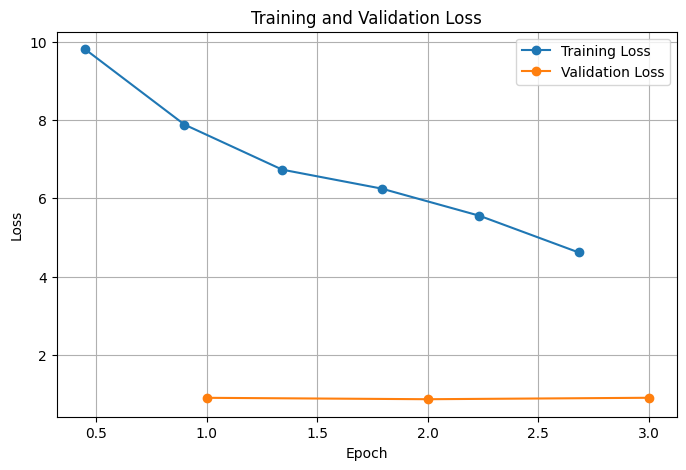

In [27]:
import matplotlib.pyplot as plt

train_epochs, train_losses = [], []
eval_epochs, eval_losses = [], []

for entry in trainer.state.log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_epochs.append(entry["epoch"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_epochs.append(entry["epoch"])
        eval_losses.append(entry["eval_loss"])

plt.figure(figsize=(8,5))
plt.plot(train_epochs, train_losses, marker="o", label="Training Loss")
plt.plot(eval_epochs, eval_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("/kaggle/working/loss_curve.png")
plt.show()

In [28]:
import shutil
shutil.make_archive("/kaggle/working/final_model", "zip", "/kaggle/working/final_model")
print("Zipped to /kaggle/working/final_model.zip")

import os
size_mb = os.path.getsize("/kaggle/working/final_model.zip") / (1024*1024)
print(f"Size: {size_mb:.1f} MB")

Zipped to /kaggle/working/final_model.zip
Size: 794.8 MB
